Importing the rietX module - and running the capabilities to check it imported

In [2]:
import rietx as rx
from rietx.schemas.instrument import BackgroundChebyshev
from rietx import capabilities
import matplotlib.pyplot as plt  

caps = capabilities()
caps.package_version
print(caps.package_version)
[backend.name for backend in caps.backends if backend.available]
[fmt.name for fmt in caps.reader_formats]

1.3.0


['bruker_raw',
 'rasx',
 'brml',
 'ras',
 'uxd',
 'xrdml',
 'pdcif',
 'gsas',
 'chi',
 'dif_peaklist',
 'xy']

Importing some example data - benzimidazole alpha on kapton backing measured in transmission

In [3]:
data = rx.read_pattern("10102023 LLTest_B4_PB8_SYC_HTTrans_4-40_60min_batch.xrdml")
data.metadata #you can easily read the metadata from the xrdml file header - nice for your own notes. Note count time is not total scan time. 

{'source_file': '10102023 LLTest_B4_PB8_SYC_HTTrans_4-40_60min_batch.xrdml',
 'format': 'xrdml',
 'scan': '0',
 'scan_count': '1',
 'sample': '10102023 LLTest_PB8_SYC_HTTrans_4-40_60min_batch',
 'scan_axis': 'Gonio',
 'anode': 'Cu',
 'wavelength': '1.540598',
 'wavelength_alpha2': '1.544426',
 'intensity_unit': 'counts',
 'count_time_s': '304.47',
 'goniometer_radius_mm': '240.0'}

Using matplotlib to quickly visualise our raw data and check it looks like how we think it should

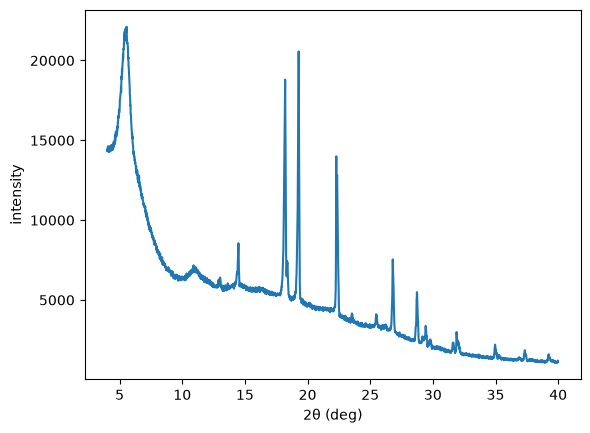

In [4]:
plt.plot(data.tt(), data.y())
plt.xlabel("2θ (deg)")
plt.ylabel("intensity")
plt.show()

By telling rietx the wavelength - in this case CuKalpha 1 + 2 the software can check for the pressence of Kbeta peaks. 

In [18]:
diagnose_data =  rx.diagnose(data, wavelength=1.5406)

for diagnostic in diagnose_data:
    print(diagnostic)

('n_points', 2742)
('two_theta_min', 4.00356514)
('two_theta_max', 39.99366996)
('baseline_lambda', 1000000.0)
('noise_sigma_median', 66.56951243547172)
('peak_fraction', 0.6663019693654267)
('n_peaks', 292)
('peak_density_per_deg', 8.113341193653127)
('signal_to_background', 3.7595555656202926)
('amorphous_hump_score', 0.06083695161978921)
('air_scatter_gain', 0.9313342134048255)
('steps_per_fwhm', 9.400044409437896)
('n_peaks_measured', 23)
('contamination', [ContaminationFlag(kind='kbeta', two_theta=16.39855198789493, parent_two_theta=18.21053099743889, intensity_ratio=0.031031618028429298), ContaminationFlag(kind='kbeta', two_theta=16.437942835928492, parent_two_theta=18.21053099743889, intensity_ratio=0.03317885223500152), ContaminationFlag(kind='kbeta', two_theta=16.503594249317768, parent_two_theta=18.21053099743889, intensity_ratio=0.028116336849900714), ContaminationFlag(kind='kbeta', two_theta=4.896424362094126, parent_two_theta=5.552938495986866, intensity_ratio=0.2905710781

adding a model for our instrument - which we know is a flat plate transmission with Cu Kalpha radiation

In [22]:
instrument = rx.Instrument.flat_plate_transmission(radiation= "CuKa")
instrument.background = BackgroundChebyshev.with_terms(3) # adding a background function



#quickly reading out properties of our instrument 
for item in instrument:
    for sub in item:
        print(sub)

source
kind='xray_cw' lines=[EmissionLine(wavelength=Parameter(value=1.5405929, vary=False, min=0.001, max=inf, expr=None, transform='identity', unit='A', stderr=None), weight=Parameter(value=1.0, vary=False, min=0.0, max=2.0, expr=None, transform='identity', unit=None, stderr=None)), EmissionLine(wavelength=Parameter(value=1.5444274, vary=False, min=0.001, max=inf, expr=None, transform='identity', unit='A', stderr=None), weight=Parameter(value=0.5, vary=False, min=0.0, max=1.0, expr=None, transform='identity', unit=None, stderr=None))] polarization=Parameter(value=0.5, vary=False, min=0.0, max=1.0, expr=None, transform='identity', unit=None, stderr=None) dispersion=Dispersion(table='cromer_liberman', overrides={}) harmonics=[]
geometry
kind='flat_plate_transmission' goniometer_radius_mm=None surface_roughness=None sample_displacement=Parameter(value=0.0, vary=False, min=-1.0, max=1.0, expr=None, transform='identity', unit='mm', stderr=None) sample_transparency=Parameter(value=0.0, var

Adding the structural information about the model from a cif file

In [23]:
structure = rx.Structure.from_cif("1118210.cif")

#this simply gives a name to the phase for plotting
phase = structure.phases[0] 
phase.name = "bIm" 

#check that your cif read in right - the unit cell information is important for us - the atoms not as much right now
print(f"phase: {phase.name}, {phase.space_group}, a={phase.cell.a.value} A, b = {phase.cell.b.value} A, c = {phase.cell.c.value} A "
      f"{len(phase.atoms)} asymmetric atoms")

phase: bIm, P n a 21, a=13.507 A, b = 6.789 A, c = 6.94 A 9 asymmetric atoms


Running a refinement using the refinement object

In [24]:
ref = rx.Refinement(structure= structure, instrument = instrument)


Running a Le Bail fit

In [25]:
lebail = ref.fit(data, mode = 'lebail')



Seeing the results of your fit and looking at the statistics

In [26]:


a_lb = ref.fitted_structure.phases[0].cell.a.value
b_lb = ref.fitted_structure.phases[0].cell.b.value
c_lb = ref.fitted_structure.phases[0].cell.c.value


print(f"\nLe Bail:  status={lebail.status}  Rwp={lebail.statistics.rwp:.4f}  "
      f"GoF={lebail.statistics.gof:.2f}  a={a_lb:.6f} A b={b_lb} A c={c_lb} A ")



print(lebail)


Le Bail:  status=converged  Rwp=0.2240  GoF=16.06  a=13.591295 A b=6.748889856456957 A c=6.93323257793884 A 
RefinementResult: converged (lebail)
  stage bkg: converged (14 it, ftol=1e-06)
  stage zero: max_iter (400 it, ftol=1e-06)
  stage cell: converged (243 it, ftol=1e-06)
  stage profile_w: converged (20 it, ftol=1e-06)
  stage profile: converged (40 it, ftol=solver default), max|Δθ|/esd=0.000
  diagnostics: 1 unresolved
    WARNING STAGE_MAX_ITER: stage 'zero' stopped on its iteration budget rather than converging — the parameters freed there are probably degenerate (the agent skill §3) rather than merely slow: free fewer at once, or check the diagnostics for a correlation or bound hit in the same stage — raising max_iter buys solver evaluations, not a different minimum
  provenance: rietx 1.3.0, backend=numpy, solver=trf
  Rwp 0.2240 / Rexp 0.0139 (GoF 16.06), Rp 0.1817, χ² 258.0, DW 0.02


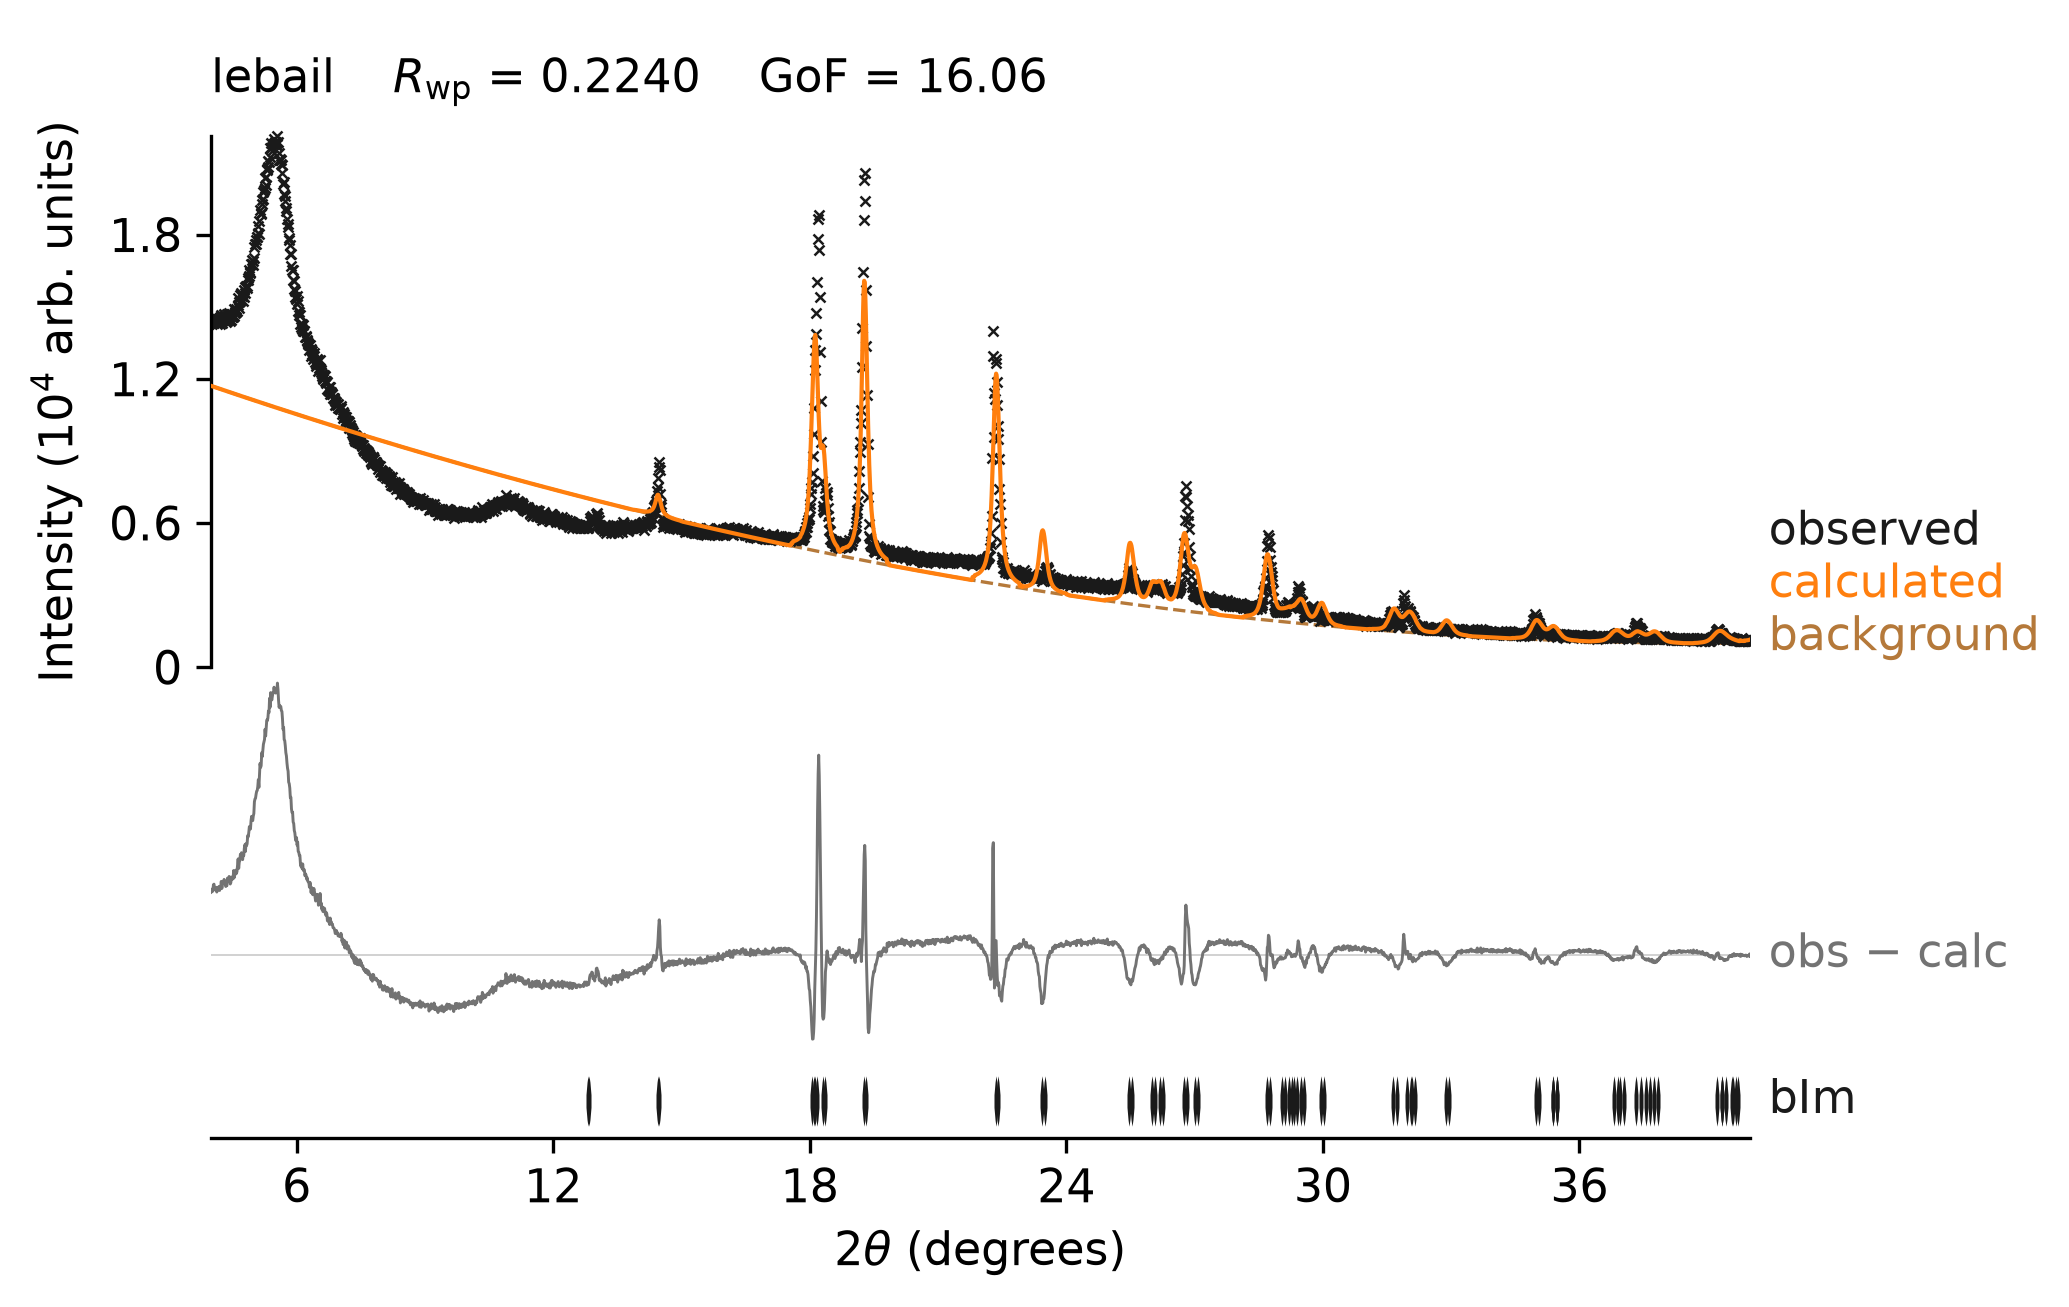

In [27]:
lebail.plot(path = "bIm_LeBail1.png")

The fit is not the best - either statistically or visually. The result says the problem is the zero peak shift, but we can see its probably actualy the background - lets cut the data around the kapton peak.

In [28]:
limits = (12, 36)
lebail2 = ref.fit(data, mode = 'lebail', two_theta_limits=limits)



Seeing the result of the second fit

In [29]:
a_lb = ref.fitted_structure.phases[0].cell.a.value
b_lb = ref.fitted_structure.phases[0].cell.b.value
c_lb = ref.fitted_structure.phases[0].cell.c.value
print(f"\nLe Bail:  status={lebail2.status}  Rwp={lebail2.statistics.rwp:.4f}  "
      f"GoF={lebail.statistics.gof:.2f}  a={a_lb:.6f} A b={b_lb} A c={c_lb} A ")

print(lebail2)


Le Bail:  status=converged  Rwp=0.1278  GoF=16.06  a=13.522297 A b=6.593942056963683 A c=6.870172376570012 A 
RefinementResult: converged (lebail)
  stage bkg: converged (2 it, ftol=1e-06)
  stage zero: converged (4 it, ftol=1e-06)
  stage cell: converged (49 it, ftol=1e-06)
  stage profile_w: converged (35 it, ftol=1e-06)
  stage profile: converged (63 it, ftol=solver default), max|Δθ|/esd=0.000
  diagnostics: 1 unresolved
    WARNING HIGH_CORRELATION: instrument.profile.x ~ instrument.profile.y (ρ=-0.988) — consider fixing one of the correlated parameters
  provenance: rietx 1.3.0, backend=numpy, solver=trf
  Rwp 0.1278 / Rexp 0.0158 (GoF 8.11), Rp 0.0854, χ² 65.7, DW 0.11


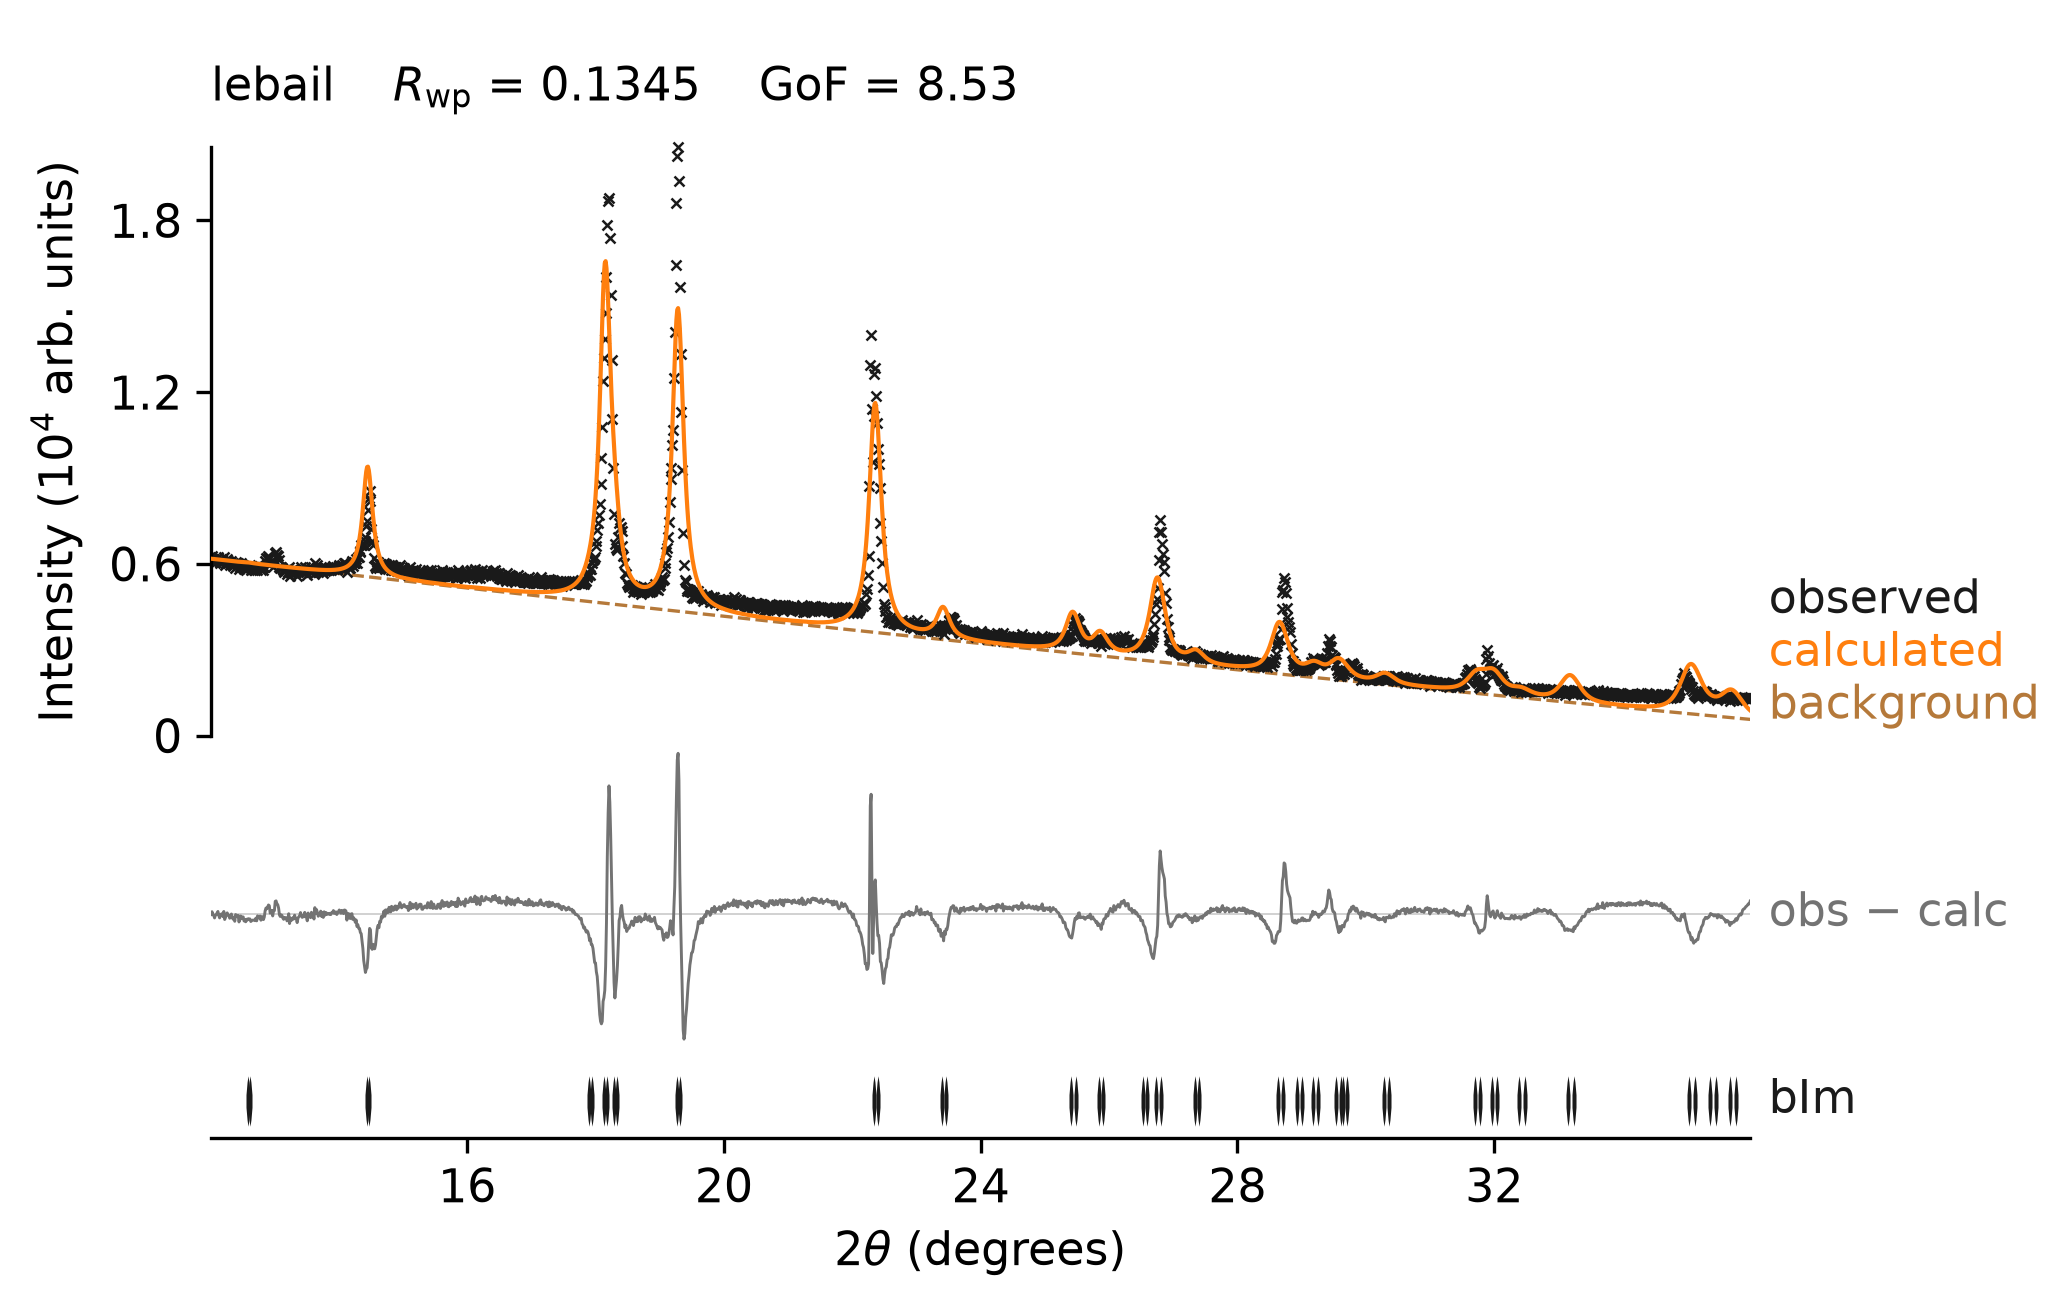

In [14]:
lebail2.plot(path = "bImLeBail2.png")